# AR, MA y ARMA sobre tdb (ClimaLab / ESOLMET)

Construimos un modelo lineal estacionario para la temperatura horaria.
El orden del notebook sigue la narrativa estándar de Box-Jenkins:

1. Cargar y resamplear.
2. Hacer la serie **estacionaria** (quitar nivel y estacionalidad diaria).
3. Identificar órdenes (`p`, `q`) con ACF/PACF.
4. Estimar AR(p), MA(q) y ARMA(p, q).
5. Diagnosticar residuales (¿se parecen a ruido blanco?).
6. Comparar con AIC/BIC y pronosticar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Carga y resampleo a 1 hora

Trabajamos a resolución horaria. A 1 minuto la serie es demasiado pesada
para ajustar ARMA y, sobre todo, dominada por ruido del sensor que no es
lo que queremos modelar.

In [2]:
tdb = pd.read_parquet(
    "../data/ClimaLab_2023-05-31_2025-06-20.parquet",
    columns=["tdb"],
)
tdb = tdb.tz_localize("America/Mexico_City",
                      nonexistent="shift_forward",
                      ambiguous="NaT")
tdb.head()

variable,tdb
date,
2023-05-31 18:59:00-06:00,27.78
2023-05-31 19:00:00-06:00,27.73
2023-05-31 19:01:00-06:00,27.71
2023-05-31 19:02:00-06:00,27.69
2023-05-31 19:03:00-06:00,27.65


In [3]:
# Resampleamos a horaria y nos quedamos con la columna como Series.
# Conservamos el nombre tdb: la entidad sigue siendo "temperatura de bulbo seco".
tdb_h = tdb["tdb"].resample("h").mean().dropna()
print(f"tdb horaria: {len(tdb_h):,} puntos "
      f"(de {tdb_h.index.min()} a {tdb_h.index.max()})")
tdb_h.head()

tdb horaria: 17,982 puntos (de 2023-05-31 18:00:00-06:00 a 2025-06-20 00:00:00-06:00)


date
2023-05-31 18:00:00-06:00    27.780000
2023-05-31 19:00:00-06:00    27.291500
2023-05-31 20:00:00-06:00    26.672034
2023-05-31 21:00:00-06:00    25.673729
2023-06-01 07:00:00-06:00    24.996296
Name: tdb, dtype: float64

## 2. Recorte a una ventana manejable

Para ajustar AR/MA/ARMA *no estacionales* necesitamos una serie
razonablemente estacionaria. La serie completa tiene ciclo anual marcado
(lo vimos en 013), así que tomamos **un mes** donde el régimen
meteorológico cambia poco — ahí el modelo lineal tiene chance.

tdb_mes: 744 horas (~31 días)


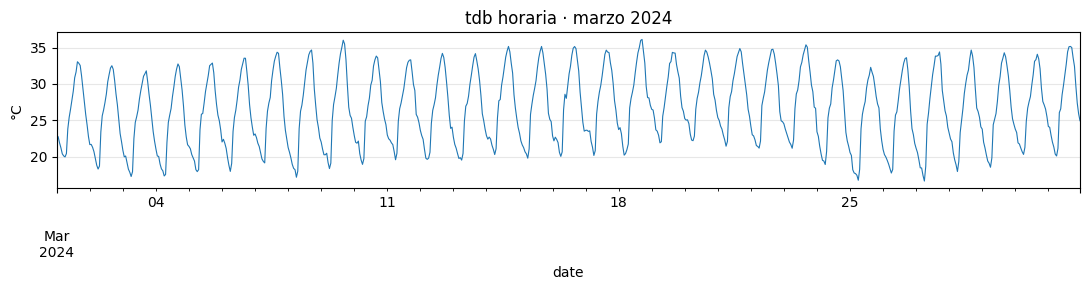

In [4]:
tdb_mes = tdb_h.loc["2024-03"].copy()
print(f"tdb_mes: {len(tdb_mes)} horas (~{len(tdb_mes)/24:.0f} días)")

fig, ax = plt.subplots(figsize=(11, 3))
tdb_mes.plot(ax=ax, lw=0.8)
ax.set_title("tdb horaria · marzo 2024")
ax.set_ylabel("°C")
plt.tight_layout(); plt.show()

Aun en un mes, lo que **domina visualmente** es el ciclo diario.
Un ARMA puro no modela estacionalidad: o la diferenciamos, o la
restamos. Vamos por la segunda vía porque es más interpretable.

## 3. Quitar la estacionalidad diaria

Construimos una **climatología horaria** del mes (promedio por hora del
día) y la restamos. Lo que queda es la *anomalía* respecto a "lo típico
a esta hora": ahí es donde vive la dinámica que un ARMA puede capturar.

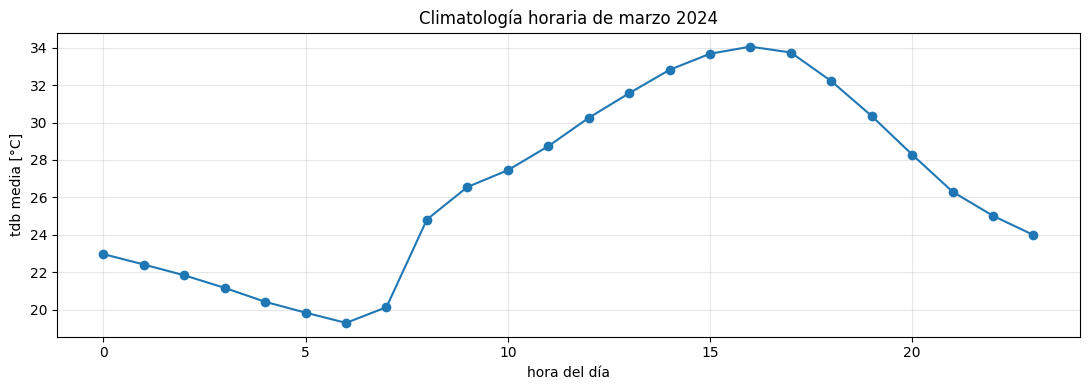

In [5]:
clima_horaria = tdb_mes.groupby(tdb_mes.index.hour).mean()
clima_horaria.plot(marker="o")
plt.title("Climatología horaria de marzo 2024")
plt.xlabel("hora del día"); plt.ylabel("tdb media [°C]")
plt.tight_layout(); plt.show()

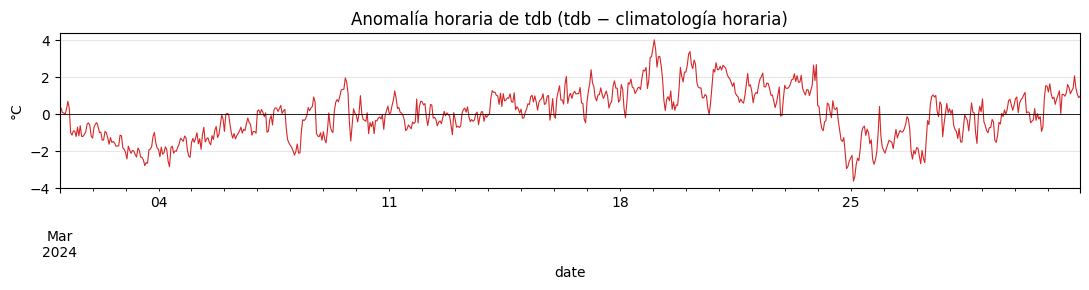

In [6]:
# Restamos a cada timestamp su valor climatológico según la hora.
tdb_anom = tdb_mes - tdb_mes.index.hour.map(clima_horaria)

fig, ax = plt.subplots(figsize=(11, 3))
tdb_anom.plot(ax=ax, lw=0.8, color="C3")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Anomalía horaria de tdb (tdb − climatología horaria)")
ax.set_ylabel("°C")
plt.tight_layout(); plt.show()

Ya no hay un ciclo diario evidente; oscila alrededor de cero. Esa es la
serie sobre la que trabajaremos: la llamamos `tdb_anom`.

## 4. ¿Es estacionaria? — Prueba ADF

La prueba de **Dickey-Fuller aumentada** tiene como hipótesis nula
"la serie tiene una raíz unitaria" (≈ no es estacionaria). Si el p-value
es chico, rechazamos H₀ y podemos seguir con ARMA.

In [7]:
def adf_report(serie, nombre):
    stat, p, *_ = adfuller(serie, autolag="AIC")
    print(f"ADF · {nombre}")
    print(f"  estadístico = {stat:.3f}")
    print(f"  p-value     = {p:.4f}")
    print(f"  → {'estacionaria' if p < 0.05 else 'NO estacionaria'} (α=0.05)")

adf_report(tdb_mes,  "tdb_mes  (con estacionalidad)")
adf_report(tdb_anom, "tdb_anom (anomalía)")

ADF · tdb_mes  (con estacionalidad)
  estadístico = -2.282
  p-value     = 0.1779
  → NO estacionaria (α=0.05)
ADF · tdb_anom (anomalía)
  estadístico = -1.724
  p-value     = 0.4188
  → NO estacionaria (α=0.05)


## 5. Identificación de órdenes con ACF y PACF

Reglas de bolsillo de Box-Jenkins:

| Forma                       | Modelo sugerido | Orden          |
|-----------------------------|-----------------|----------------|
| PACF corta en lag `p`, ACF decae | AR(p)       | `p`            |
| ACF corta en lag `q`, PACF decae | MA(q)       | `q`            |
| Ambas decaen                | ARMA(p, q)      | mirar las dos  |

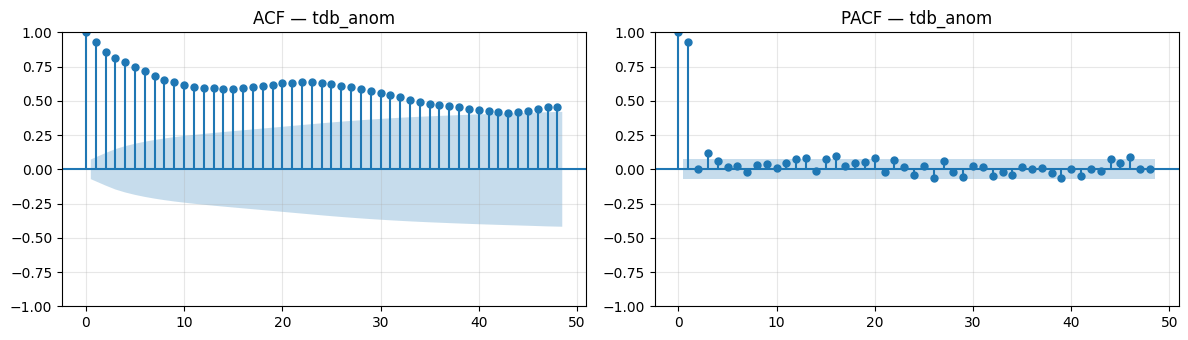

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(tdb_anom,  lags=48, ax=axes[0])
axes[0].set_title("ACF — tdb_anom")
plot_pacf(tdb_anom, lags=48, ax=axes[1], method="ywm")
axes[1].set_title("PACF — tdb_anom")
plt.tight_layout(); plt.show()

Lo que esperamos ver en este tipo de serie:

- **PACF**: pico fuerte en lag 1, mucho más pequeños después → sugiere
  AR de orden bajo (1 ó 2).
- **ACF**: decae geométricamente desde lag 1 → coherente con un AR.

Probaremos AR(1), AR(2), MA(1), MA(2) y ARMA(1, 1) y compararemos.

## 6. Modelo AR(p)

$$ y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t $$

`ARIMA(p, 0, 0)` ajusta exactamente un AR(p). Usamos `tdb_anom` directa.

In [9]:
ar1 = ARIMA(tdb_anom, order=(1, 0, 0)).fit()
print(ar1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0158      0.246      0.064      0.949      -0.467       0.499
ar.L1          0.9267      0.014     67.214      0.000       0.900       0.954
sigma2         0.2378      0.010     22.678      0.000       0.217       0.258


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [10]:
ar2 = ARIMA(tdb_anom, order=(2, 0, 0)).fit()
print(ar2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0155      0.248      0.062      0.950      -0.471       0.502
ar.L1          0.9246      0.032     28.756      0.000       0.862       0.988
ar.L2          0.0022      0.032      0.067      0.947      -0.061       0.066
sigma2         0.2378      0.010     22.675      0.000       0.217       0.258


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Lectura: `ar.L1` es $\phi_1$. En tdb horaria suele salir cercano a 0.9,
lo que confirma la fuerte memoria de corto plazo (la temperatura de
*ahora* está casi determinada por la de *hace una hora*).

## 7. Modelo MA(q)

$$ y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q} $$

Aquí la dependencia es con los **shocks** pasados, no con los valores
pasados. `ARIMA(0, 0, q)` ajusta MA(q).

In [11]:
ma1 = ARIMA(tdb_anom, order=(0, 0, 1)).fit()
print(ma1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.054      0.007      0.994      -0.106       0.106
ma.L1          0.7826      0.023     33.525      0.000       0.737       0.828
sigma2         0.6841      0.041     16.862      0.000       0.605       0.764


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [12]:
ma2 = ARIMA(tdb_anom, order=(0, 0, 2)).fit()
print(ma2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.064      0.005      0.996      -0.124       0.125
ma.L1          1.0571      0.030     35.303      0.000       0.998       1.116
ma.L2          0.5530      0.032     17.216      0.000       0.490       0.616
sigma2         0.4401      0.024     18.683      0.000       0.394       0.486


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


En esta serie el MA puro suele quedar por debajo del AR: la PACF nos
avisó de eso (corta limpiamente, no decae). Lo confirmaremos con AIC.

## 8. Modelo ARMA(p, q)

$$ y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j} $$

Combina memoria de los valores pasados y de los shocks pasados.

In [13]:
arma11 = ARIMA(tdb_anom, order=(1, 0, 1)).fit()
print(arma11.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0155      0.248      0.062      0.950      -0.471       0.502
ar.L1          0.9271      0.015     61.981      0.000       0.898       0.956
ma.L1         -0.0032      0.035     -0.091      0.927      -0.072       0.065
sigma2         0.2378      0.010     22.675      0.000       0.217       0.258


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [14]:
arma21 = ARIMA(tdb_anom, order=(2, 0, 1)).fit()
print(arma21.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0149      0.244      0.061      0.951      -0.463       0.493
ar.L1          0.3631      0.594      0.611      0.541      -0.801       1.527
ar.L2          0.5178      0.552      0.937      0.349      -0.565       1.600
ma.L1          0.5942      0.580      1.025      0.305      -0.542       1.730
sigma2         0.2374      0.010     22.671      0.000       0.217       0.258


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-

## 9. Diagnóstico de residuales

Un buen modelo deja residuales **≈ ruido blanco**: media cero, sin
autocorrelación, varianza estable. Tres herramientas:

1. **ACF de residuales** — debe estar dentro de las bandas.
2. **Ljung-Box** — H₀: no hay autocorrelación hasta el lag k.
3. **Inspección visual** del residual y su histograma.

In [15]:
def diagnostico(modelo, nombre, lags=24):
    resid = modelo.resid
    # Statsmodels mete un transitorio en los primeros pasos: lo descartamos.
    resid = resid.iloc[max(modelo.model.k_ar, modelo.model.k_ma):]

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes[0, 0].plot(resid.index, resid.values, lw=0.6)
    axes[0, 0].axhline(0, color="k", lw=0.6)
    axes[0, 0].set_title(f"Residuales · {nombre}")

    axes[0, 1].hist(resid, bins=30, color="C0", alpha=0.7)
    axes[0, 1].set_title("Histograma de residuales")

    plot_acf(resid, lags=lags, ax=axes[1, 0])
    axes[1, 0].set_title("ACF de residuales")

    plot_pacf(resid, lags=lags, ax=axes[1, 1], method="ywm")
    axes[1, 1].set_title("PACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    print()

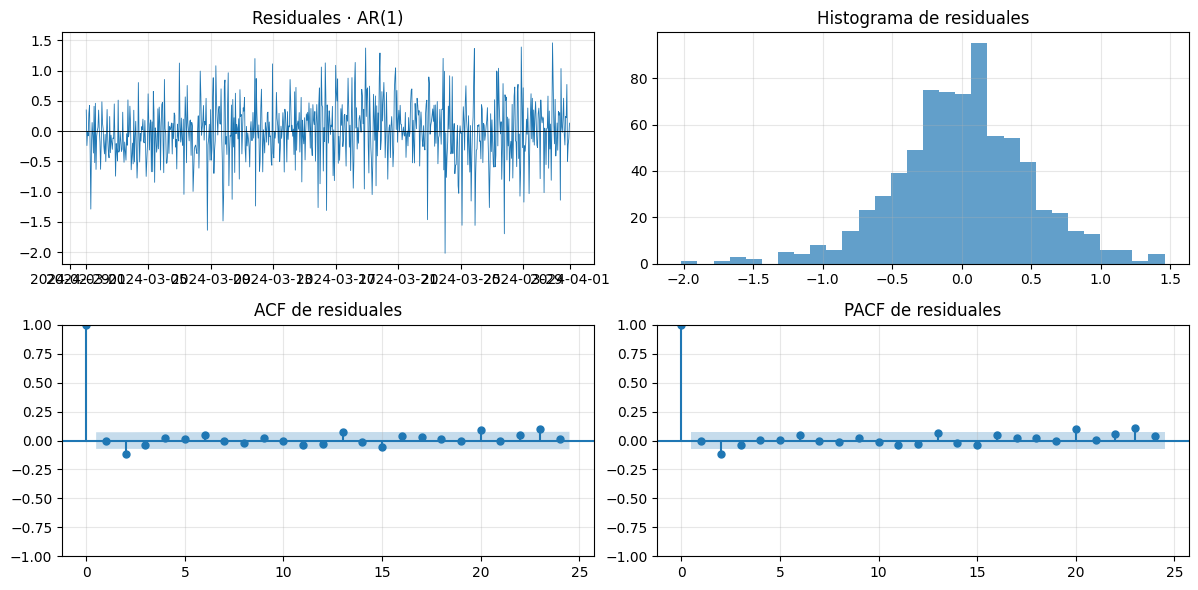

Ljung-Box · AR(1)
    lb_stat  lb_pvalue
10  13.6241     0.1908
20  30.0567     0.0689



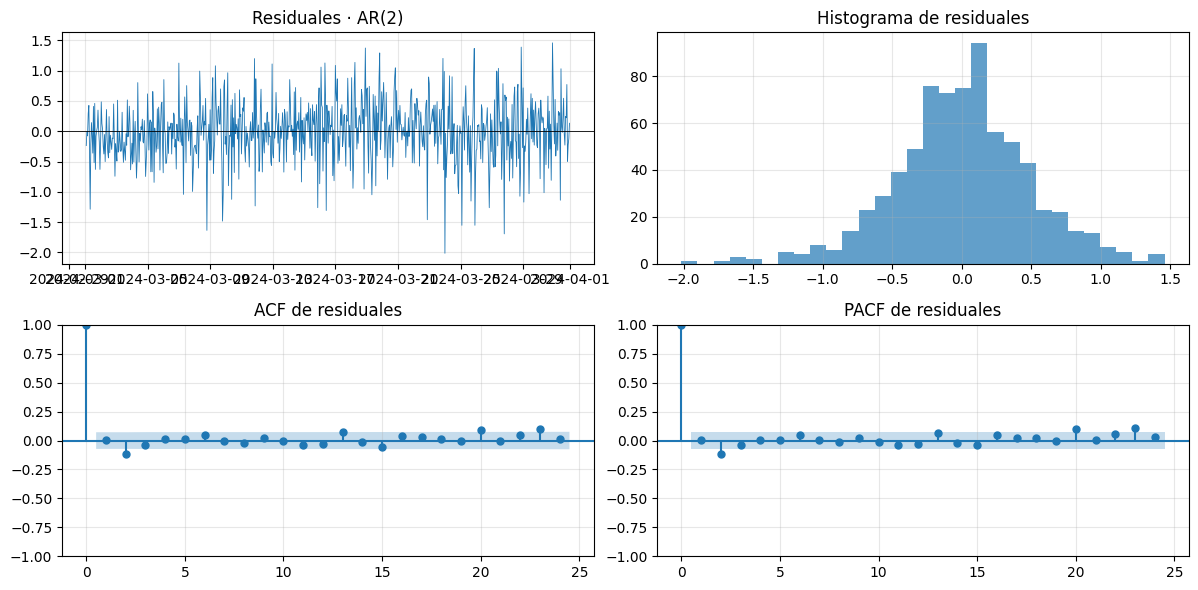

Ljung-Box · AR(2)
    lb_stat  lb_pvalue
10  13.6661     0.1888
20  30.0903     0.0684



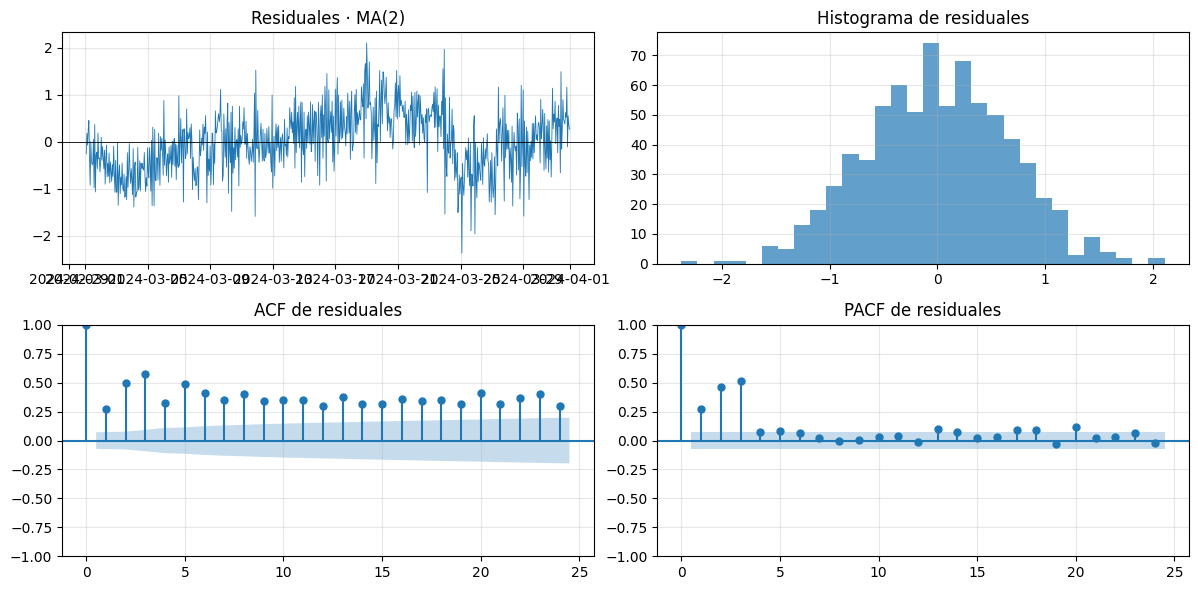

Ljung-Box · MA(2)
      lb_stat  lb_pvalue
10  1265.3395        0.0
20  2170.6660        0.0



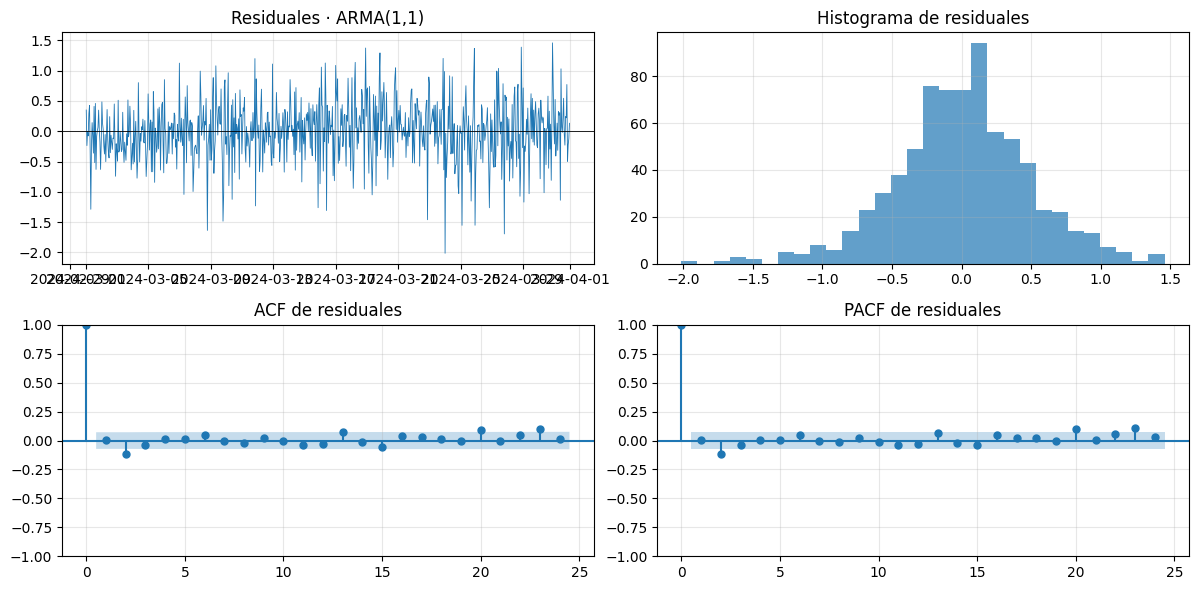

Ljung-Box · ARMA(1,1)
    lb_stat  lb_pvalue
10  13.7360     0.1854
20  30.1086     0.0681



In [16]:
diagnostico(ar1,    "AR(1)")
diagnostico(ar2,    "AR(2)")
diagnostico(ma2,    "MA(2)")
diagnostico(arma11, "ARMA(1,1)")

Si el p-value de Ljung-Box queda **por encima** de 0.05, no podemos
rechazar la hipótesis de ruido blanco — el modelo capturó la estructura.
Si queda por debajo, falta información que el modelo no recogió
(típicamente: la estacionalidad que dejamos *en* la climatología).

## 10. Comparación con AIC y BIC

Reglas: **menor AIC/BIC, mejor**. AIC tiende a elegir modelos más ricos,
BIC penaliza más la complejidad y suele preferir órdenes bajos.

In [17]:
modelos = {
    "AR(1)":     ar1,
    "AR(2)":     ar2,
    "MA(1)":     ma1,
    "MA(2)":     ma2,
    "ARMA(1,1)": arma11,
    "ARMA(2,1)": arma21,
}
tabla = pd.DataFrame({
    "AIC":    [m.aic    for m in modelos.values()],
    "BIC":    [m.bic    for m in modelos.values()],
    "loglik": [m.llf    for m in modelos.values()],
}, index=modelos.keys()).round(2)
tabla.sort_values("AIC")

,AIC,BIC,loglik
AR(1),1050.72,1064.55,-522.36
AR(2),1052.71,1071.16,-522.36
"ARMA(1,1)",1052.71,1071.16,-522.36
"ARMA(2,1)",1053.54,1076.60,-521.77
MA(2),1510.18,1528.63,-751.09
MA(1),1835.84,1849.68,-914.92


## 11. Pronóstico y validación

Con el modelo ganador haremos **dos cosas** que conviene no confundir:

- **11A · Forecast hacia adelante**: el modelo proyecta las 24 h
  siguientes al fin del entrenamiento. Para *ver* qué tan razonable es,
  superponemos los datos reales que vinieron después (que están en
  `tdb_h`, no en `tdb_mes`).
- **11B · Hold-out**: re-entrenamos sin las últimas 24 h, las
  pronosticamos y comparamos contra lo observado. Es la validación
  honesta — devuelve un error numérico (RMSE / MAE).

In [18]:
mejor = modelos[tabla["AIC"].idxmin()]
nombre_mejor = tabla["AIC"].idxmin()
print(f"Modelo elegido por AIC: {nombre_mejor}")

Modelo elegido por AIC: AR(1)


### 11A. Forecast hacia adelante con observación real superpuesta

El modelo ya fue ajustado con todo `tdb_anom` (= todo marzo). El
`get_forecast(steps=24)` cae en **1 abril 2024**. Para verlo encima de
datos reales, usamos `tdb_h` (la serie horaria completa) recortada a
una ventana que cruza el corte marzo→abril.

In [19]:
horizonte = 24
fc = mejor.get_forecast(steps=horizonte)
fc_anom = fc.predicted_mean
fc_ic   = fc.conf_int(alpha=0.05)

# Re-añadir la climatología: cada paso del pronóstico cae en una hora
# concreta del día — usamos esa hora para mapear al promedio climatológico.
horas_fc = fc_anom.index.hour
fc_real  = fc_anom + horas_fc.map(clima_horaria).values
fc_lo    = fc_ic.iloc[:, 0] + horas_fc.map(clima_horaria).values
fc_hi    = fc_ic.iloc[:, 1] + horas_fc.map(clima_horaria).values

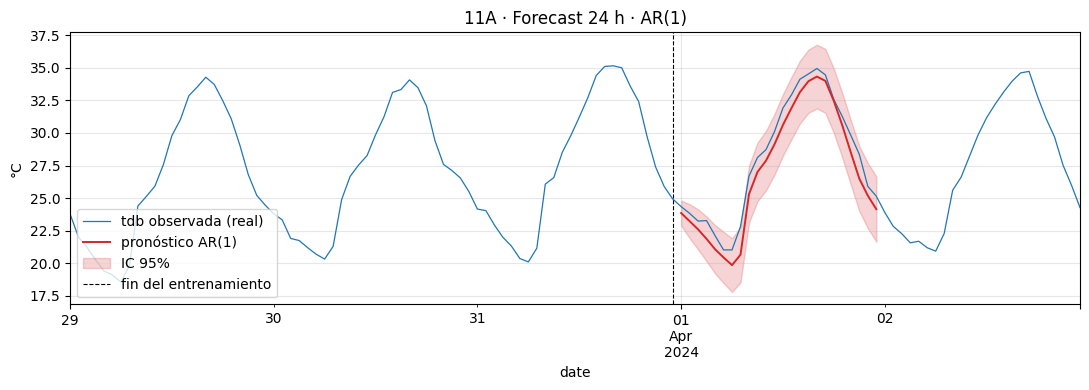

In [20]:
# Ventana de visualización: últimos 3 días de marzo + 2 días de abril.
ventana = tdb_h.loc["2024-03-29":"2024-04-02"]

fig, ax = plt.subplots(figsize=(11, 4))
ventana.plot(ax=ax, lw=0.9, label="tdb observada (real)")
fc_real.plot(ax=ax, lw=1.4, color="C3", label=f"pronóstico {nombre_mejor}")
ax.fill_between(fc_real.index, fc_lo, fc_hi, color="C3", alpha=0.2,
                label="IC 95%")
ax.axvline(tdb_mes.index[-1], color="k", ls="--", lw=0.8,
           label="fin del entrenamiento")
ax.set_title(f"11A · Forecast 24 h · {nombre_mejor}")
ax.set_ylabel("°C"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

Lectura: el pronóstico **respira** el ciclo diario porque la
climatología horaria que sumamos de regreso ya lo trae. Lo que el AR(1)
añade es la corrección de "anomalía persistente": si entras a abril
medio grado por debajo de la climatología, el modelo lo arrastra unas
horas antes de que la inercia de la anomalía decaiga a cero.

### 11B. Hold-out: entrenar sin las últimas 24 h y compararlas

Esta es la prueba que cuenta. Cortamos el último día de `tdb_anom`,
re-ajustamos el mismo orden de modelo en el resto, pronosticamos esas
24 h y las contrastamos contra los valores reales — que sí tenemos.

In [21]:
train_anom = tdb_anom.iloc[:-24]
test_anom  = tdb_anom.iloc[-24:]

# Re-ajustamos exactamente el mismo orden ganador.
orden_mejor = mejor.model.order  # (p, d, q)
mejor_ho    = ARIMA(train_anom, order=orden_mejor).fit()

fc_ho      = mejor_ho.get_forecast(steps=24)
pred_anom  = fc_ho.predicted_mean
pred_ic    = fc_ho.conf_int(alpha=0.05)

# Devolvemos pronóstico y test a °C reales sumando la climatología.
horas_test = test_anom.index.hour
clima_test = horas_test.map(clima_horaria).values

pred_real = pred_anom        + clima_test
pred_lo   = pred_ic.iloc[:, 0] + clima_test
pred_hi   = pred_ic.iloc[:, 1] + clima_test
real_obs  = test_anom        + clima_test

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [22]:
# Métricas de error sobre las 24 h reservadas.
err  = real_obs.values - pred_real.values
rmse = np.sqrt(np.mean(err ** 2))
mae  = np.mean(np.abs(err))
print(f"Hold-out · {nombre_mejor} · 24 h")
print(f"  RMSE = {rmse:.2f} °C")
print(f"  MAE  = {mae:.2f} °C")

Hold-out · AR(1) · 24 h
  RMSE = 0.72 °C
  MAE  = 0.60 °C


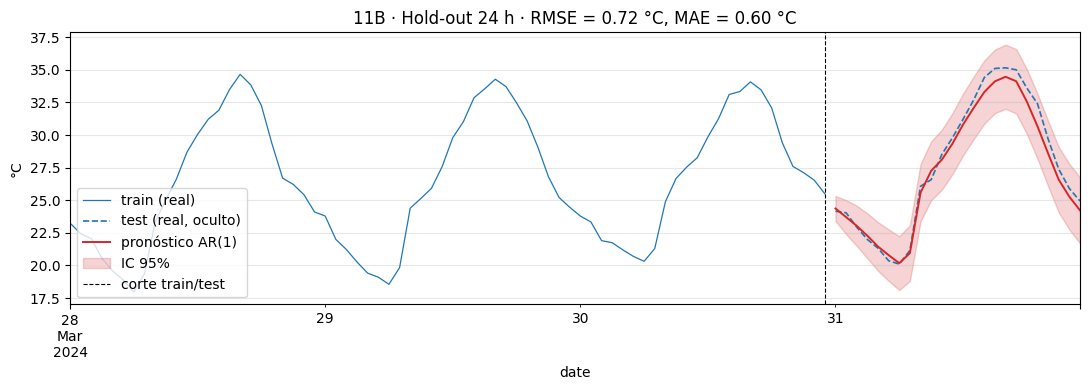

In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
# Contexto: los 3 días previos al hold-out (todos del entrenamiento).
contexto = (train_anom.iloc[-72:]
            + train_anom.iloc[-72:].index.hour.map(clima_horaria).values)
contexto.plot(ax=ax, lw=0.9, color="C0", label="train (real)")
real_obs.plot(ax=ax, lw=1.2, color="C0", ls="--", label="test (real, oculto)")
pred_real.plot(ax=ax, lw=1.4, color="C3", label=f"pronóstico {nombre_mejor}")
ax.fill_between(pred_real.index, pred_lo, pred_hi, color="C3", alpha=0.2,
                label="IC 95%")
ax.axvline(train_anom.index[-1], color="k", ls="--", lw=0.8,
           label="corte train/test")
ax.set_title(f"11B · Hold-out 24 h · RMSE = {rmse:.2f} °C, MAE = {mae:.2f} °C")
ax.set_ylabel("°C"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

**Cómo leer este gráfico.**

- Línea azul continua: lo que el modelo *vio* al entrenar.
- Línea azul punteada: lo que se le ocultó.
- Línea roja: lo que el modelo dice que va a pasar en esas 24 h.
- Banda rosa: IC 95% — debería contener a la línea punteada la mayor
  parte del tiempo si el modelo está bien calibrado.

Si la línea roja se queda *plana en la climatología* mientras la real
hace un swing fuerte, esa es la limitación de un AR(1) con
climatología fija: no sabe nada de frentes fríos, nubosidad ni
advección — sólo memoria a corto plazo de la anomalía.

## 12. Síntesis

- Para que un ARMA tenga sentido la serie debe ser **estacionaria**:
  aquí lo logramos restando la climatología horaria.
- **PACF → p**, **ACF → q**. La forma de cada una sugiere AR puro,
  MA puro o mezcla.
- El diagnóstico **no es opcional**: un AIC bajo con residuales todavía
  autocorrelados es un modelo que parece bueno y no lo es.
- El siguiente paso natural (sesión 7) es **SARIMA**: en lugar de
  restarle la estacionalidad a mano, dejar que el modelo la absorba con
  un componente estacional explícito ($s = 24$).